## Setup and config

This section imports core libraries and defines the key paths plus sampling knobs used in the EDA. The defaults keep runs fast while still touching multiple ROIs.

- Update `DATA_ROOT` if your dataset is in a different location.
- Increase `N_ROI_SAMPLE` and `N_PATCH_PER_ROI` for deeper coverage.


In [17]:
import sys
sys.executable


'c:\\Users\\bumba\\OneDrive\\Documents\\Spring 26\\Lock Docks\\SEN12MS\\.venv\\Scripts\\python.exe'

In [18]:
from pathlib import Path
import random
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt

# GeoTIFF reading
import rasterio
from rasterio.errors import RasterioIOError

# -----------------------------
# CONFIG: update paths + sampling
# -----------------------------
DATA_ROOT = Path(r"C:\Users\bumba\OneDrive\Documents\Spring 26\Lock Docks\SEN12MS\ROIs1158_spring_s2\ROIs1158_spring")
ROI_GLOB = "s2_*"
ROI_DIR = DATA_ROOT / "s2_1"
DATASETS_ROOT = DATA_ROOT.parent.parent

# Sampling knobs for multi-ROI EDA
N_SAMPLE = 30
N_ROI_SAMPLE = 20
N_PATCH_PER_ROI = 5
PIXELS_PER_FILE = 5000
HIST_BINS = 200

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

if not ROI_DIR.exists():
    _roi_dirs = sorted([p for p in DATA_ROOT.glob(ROI_GLOB) if p.is_dir()])
    ROI_DIR = _roi_dirs[0] if _roi_dirs else DATA_ROOT

# Placeholders for outputs at the end
opt_global_stats_df = None
opt_corr_df = None
roi_deviation_df = None


## Find patch files

We start with a single ROI (Region of Interest) folder to sanity-check file discovery and show a few patch names.


In [19]:
roi_dirs = sorted([p for p in DATA_ROOT.glob(ROI_GLOB) if p.is_dir()])

def iter_all_tifs(roi_dirs):
    for roi in roi_dirs:
        yield from roi.glob("*.tif")


def count_all_tifs(roi_dirs):
    return sum(1 for _ in iter_all_tifs(roi_dirs))


def sample_tif_paths(roi_dirs, n, seed=SEED):
    rng = random.Random(seed)
    sample = []
    if n <= 0:
        return sample
    for i, p in enumerate(iter_all_tifs(roi_dirs)):
        if i < n:
            sample.append(p)
        else:
            j = rng.randint(0, i)
            if j < n:
                sample[j] = p
    return sample


def sample_patches_in_roi(roi_dir, n, seed=SEED):
    paths = list(roi_dir.glob("*.tif"))
    if not paths:
        return []
    rng = random.Random(seed)
    if len(paths) <= n:
        return paths
    return rng.sample(paths, n)


tifs = sorted(ROI_DIR.glob("*.tif"))
print(f"Found {len(tifs)} tif files in:\n  {ROI_DIR}")
  
print("First 5:")
for p in tifs[:5]:
    print(" ", p.name)

print(f"ROI dirs found: {len(roi_dirs)}")

_total_tifs = count_all_tifs(roi_dirs) if roi_dirs else 0
if roi_dirs:
    print(f"Total tif files (all ROIs): {_total_tifs}")

sample_paths = sample_tif_paths(roi_dirs, min(N_SAMPLE, _total_tifs), seed=SEED) if roi_dirs else []
print(f"Sampled {len(sample_paths)} files for dataset-wide EDA")


Found 784 tif files in:
  C:\Users\bumba\OneDrive\Documents\Spring 26\Lock Docks\SEN12MS\ROIs1158_spring_s2\ROIs1158_spring\s2_1
First 5:
  ROIs1158_spring_s2_1_p100.tif
  ROIs1158_spring_s2_1_p101.tif
  ROIs1158_spring_s2_1_p102.tif
  ROIs1158_spring_s2_1_p103.tif
  ROIs1158_spring_s2_1_p104.tif
ROI dirs found: 56
Total tif files (all ROIs): 40883
Sampled 30 files for dataset-wide EDA


## Inspect one file (metadata + array stats)

We read one GeoTIFF to verify metadata, band count, and value ranges before doing any large-scale aggregation.


Example: C:\Users\bumba\OneDrive\Documents\Spring 26\Lock Docks\SEN12MS\ROIs1158_spring_s2\ROIs1158_spring\s2_1\ROIs1158_spring_s2_1_p100.tif
=== METADATA ===
path: C:\Users\bumba\OneDrive\Documents\Spring 26\Lock Docks\SEN12MS\ROIs1158_spring_s2\ROIs1158_spring\s2_1\ROIs1158_spring_s2_1_p100.tif
driver: GTiff
width: 256
height: 256
count_bands: 13
dtypes: ('uint16', 'uint16', 'uint16', 'uint16', 'uint16', 'uint16', 'uint16', 'uint16', 'uint16', 'uint16', 'uint16', 'uint16', 'uint16')
crs: EPSG:32737
transform: | 10.00, 0.00, 390772.34|
| 0.00,-10.00, 8114182.84|
| 0.00, 0.00, 1.00|
nodata: None
=== PER-BAND STATS ===
{'band': 1, 'min': 1105.0, 'max': 1938.0, 'mean': 1311.4232025146484, 'std': 136.3184521258514, 'nan_frac': 0.0, 'zero_frac': 0.0, 'p1': 1119.0, 'p5': 1135.0, 'p50': 1287.0, 'p95': 1557.0, 'p99': 1749.0}
{'band': 2, 'min': 767.0, 'max': 2383.0, 'mean': 1091.6090087890625, 'std': 212.5734904674282, 'nan_frac': 0.0, 'zero_frac': 0.0, 'p1': 826.0, 'p5': 855.0, 'p50': 1038.0,

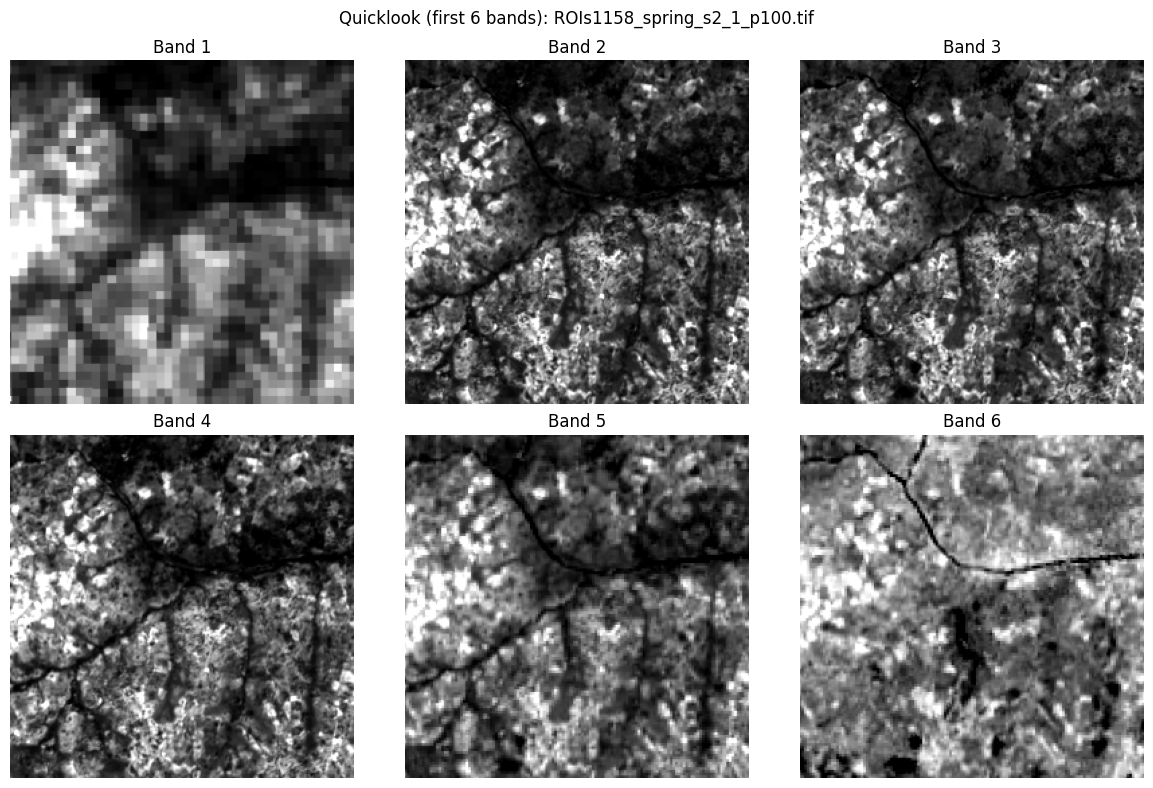

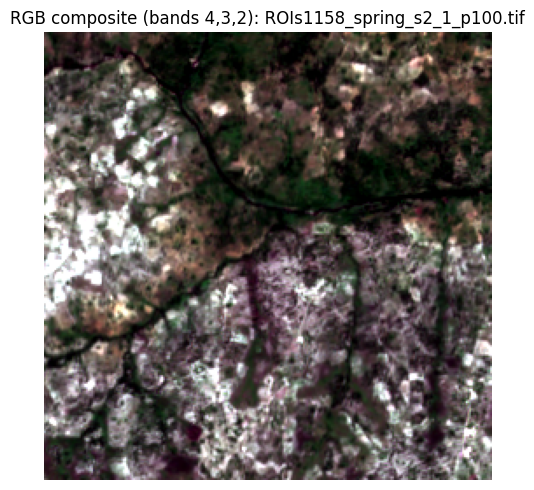

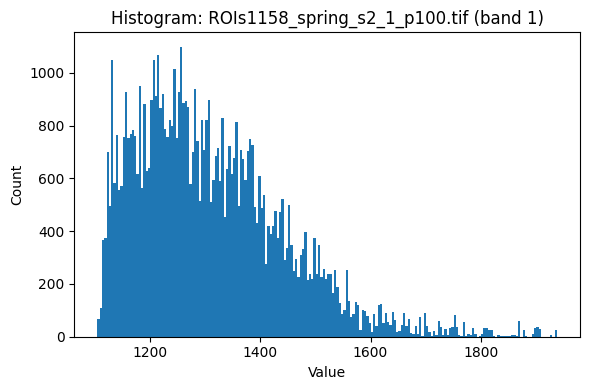

In [20]:
def _normalize_labels(labels, band_count):
    if labels and any(labels):
        out = []
        for i, lab in enumerate(labels):
            out.append(str(lab) if lab else f"B{i+1}")
        return out
    return [f"B{i+1}" for i in range(band_count)]


def _stretch_to_unit(x, p_low=2, p_high=98):
    x = x.astype(np.float32)
    finite = np.isfinite(x)
    if finite.sum() == 0:
        return np.zeros_like(x, dtype=np.float32)
    vmin, vmax = np.percentile(x[finite], [p_low, p_high])
    if vmax <= vmin:
        vmax = vmin + 1e-6
    y = (x - vmin) / (vmax - vmin)
    y = np.clip(y, 0, 1)
    y[~finite] = 0
    return y


def _guess_rgb_indices(labels, band_count):
    if labels:
        lower = [(l or "").lower() for l in labels]
        def find_idx(keys):
            for i, l in enumerate(lower):
                if any(k in l for k in keys):
                    return i + 1
            return None
        r = find_idx(["b4", "b04", "red"])
        g = find_idx(["b3", "b03", "green"])
        b = find_idx(["b2", "b02", "blue"])
        if r and g and b:
            return r, g, b
    if band_count >= 4:
        return 4, 3, 2
    if band_count >= 3:
        return 3, 2, 1
    return None


def inspect_tif(path: Path, show_plot=True, hist_band=1):
    print(f"Example: {path}")
    try:
        with rasterio.open(path) as ds:
            print("=== METADATA ===")
            print(f"path: {path}")
            print(f"driver: {ds.driver}")
            print(f"width: {ds.width}")
            print(f"height: {ds.height}")
            print(f"count_bands: {ds.count}")
            print(f"dtypes: {ds.dtypes}")
            print(f"crs: {ds.crs}")
            print(f"transform: {ds.transform}")
            print(f"nodata: {ds.nodata}")
            labels = list(ds.descriptions) if ds.descriptions else None
            if labels and any(labels):
                print(f"band_descriptions: {labels}")
            arr = ds.read()  # (bands, H, W)
            nodata = ds.nodata
    except RasterioIOError as e:
        print(f"Failed to open: {e}")
        return None

    per_band_stats = []
    print("=== PER-BAND STATS ===")
    for b in range(arr.shape[0]):
        x = arr[b].astype(np.float64)
        if nodata is not None:
            x = np.where(x == nodata, np.nan, x)
        finite = np.isfinite(x)
        nan_frac = 1.0 - np.mean(finite)
        if finite.any():
            xf = x[finite]
            p1, p5, p50, p95, p99 = np.percentile(xf, [1, 5, 50, 95, 99])
            stats = {
                "band": b + 1,
                "min": float(np.min(xf)),
                "max": float(np.max(xf)),
                "mean": float(np.mean(xf)),
                "std": float(np.std(xf)),
                "nan_frac": float(nan_frac),
                "zero_frac": float(np.mean(xf == 0)),
                "p1": float(p1),
                "p5": float(p5),
                "p50": float(p50),
                "p95": float(p95),
                "p99": float(p99),
            }
        else:
            stats = {
                "band": b + 1,
                "min": np.nan,
                "max": np.nan,
                "mean": np.nan,
                "std": np.nan,
                "nan_frac": float(nan_frac),
                "zero_frac": np.nan,
                "p1": np.nan,
                "p5": np.nan,
                "p50": np.nan,
                "p95": np.nan,
                "p99": np.nan,
            }
        per_band_stats.append(stats)
        print(stats)

    if show_plot:
        # Quicklooks for first up to 6 bands
        n_show = min(arr.shape[0], 6)
        cols = 3
        rows = int(np.ceil(n_show / cols))
        fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
        axes = np.array(axes).reshape(-1)
        for i in range(n_show):
            img = _stretch_to_unit(arr[i])
            axes[i].imshow(img, cmap="gray")
            axes[i].set_title(f"Band {i+1}")
            axes[i].axis("off")
        for j in range(n_show, len(axes)):
            axes[j].axis("off")
        plt.suptitle(f"Quicklook (first {n_show} bands): {path.name}")
        plt.tight_layout()
        plt.show()

        # RGB composite if possible
        rgb_idx = _guess_rgb_indices(labels, arr.shape[0])
        if rgb_idx:
            r, g, b = rgb_idx
            rgb = np.stack([
                _stretch_to_unit(arr[r - 1]),
                _stretch_to_unit(arr[g - 1]),
                _stretch_to_unit(arr[b - 1])
            ], axis=-1)
            plt.figure(figsize=(5, 5))
            plt.imshow(rgb)
            plt.title(f"RGB composite (bands {r},{g},{b}): {path.name}")
            plt.axis("off")
            plt.tight_layout()
            plt.show()
        else:
            print("RGB composite skipped (insufficient band info).")

        # Histogram for selected band
        hb = min(max(hist_band, 1), arr.shape[0])
        x = arr[hb - 1].astype(np.float64)
        if nodata is not None:
            x = np.where(x == nodata, np.nan, x)
        x = x[np.isfinite(x)]
        plt.figure(figsize=(6, 4))
        if x.size:
            plt.hist(x.ravel(), bins=HIST_BINS)
        plt.title(f"Histogram: {path.name} (band {hb})")
        plt.xlabel("Value")
        plt.ylabel("Count")
        plt.tight_layout()
        plt.show()

    return per_band_stats


# Run inspection on one example file
example_path = tifs[0] if tifs else (sample_paths[0] if sample_paths else None)
example_stats = inspect_tif(example_path) if example_path else None


## Optical scale / value-range heuristics

Detect likely reflectance scaling and flag suspicious patterns (negatives, saturation, excessive zeros).


In [21]:
def optical_scale_heuristic(per_band_stats):
    if not per_band_stats:
        print("No stats to analyze.")
        return
    print("=== OPTICAL SCALE HEURISTICS ===")
    for s in per_band_stats:
        band = s["band"]
        p99 = s["p99"]
        p95 = s["p95"]
        mx = s["max"]
        mn = s["min"]
        zero_frac = s["zero_frac"]
        nan_frac = s["nan_frac"]

        verdicts = []
        if np.isfinite(p99):
            if p99 <= 1.5:
                verdicts.append("likely 0-1 reflectance")
            elif 500 <= p99 <= 15000:
                verdicts.append("likely 0-10000 reflectance scale")
            else:
                verdicts.append("unclear scale")
        else:
            verdicts.append("insufficient data")

        warnings = []
        if np.isfinite(mn) and mn < 0:
            warnings.append("negative values")
        if np.isfinite(zero_frac) and zero_frac > 0.5:
            warnings.append("excessive zeros")
        if np.isfinite(nan_frac) and nan_frac > 0.1:
            warnings.append("possible nodata dominance")
        if np.isfinite(mx) and np.isfinite(p99) and mx != 0:
            if abs(mx - p99) / max(abs(mx), 1e-6) < 0.01 and p99 > p95:
                warnings.append("possible saturation (p99 ~ max)")

        print(f"Band {band}: {', '.join(verdicts)}")
        if warnings:
            print(f"  warnings: {', '.join(warnings)}")


optical_scale_heuristic(example_stats)


=== OPTICAL SCALE HEURISTICS ===
Band 1: likely 0-10000 reflectance scale
Band 2: likely 0-10000 reflectance scale
Band 3: likely 0-10000 reflectance scale
Band 4: likely 0-10000 reflectance scale
Band 5: likely 0-10000 reflectance scale
Band 6: likely 0-10000 reflectance scale
Band 7: likely 0-10000 reflectance scale
Band 8: likely 0-10000 reflectance scale
Band 9: likely 0-10000 reflectance scale
Band 10: unclear scale
Band 11: unclear scale
Band 12: likely 0-10000 reflectance scale
Band 13: likely 0-10000 reflectance scale


## Consistency check across patches

Check basic consistency of shapes, band counts, and dtypes across a small random subset of files.


In [22]:
def quick_consistency_check(paths, n=30, seed=SEED):
    if not paths:
        print("No paths provided.")
        return None
    rng = random.Random(seed)
    sample = paths if len(paths) <= n else rng.sample(paths, n)
    shapes = set()
    counts = set()
    dtypes = set()
    failures = []
    for p in sample:
        try:
            with rasterio.open(p) as ds:
                shapes.add((ds.height, ds.width))
                counts.add(ds.count)
                dtypes.add(ds.dtypes)
        except RasterioIOError as e:
            failures.append((p, str(e)))
    print("Unique shapes:", shapes)
    print("Unique band counts:", counts)
    print("Unique dtypes:", dtypes)
    print(f"Failed to open: {len(failures)}")
    if failures:
        for f in failures[:5]:
            print(" ", f[0], "-", f[1])
    return {"shapes": shapes, "counts": counts, "dtypes": dtypes, "failures": failures}


consistency = quick_consistency_check(sample_paths, n=min(N_SAMPLE, len(sample_paths)))


Unique shapes: {(256, 256)}
Unique band counts: {13}
Unique dtypes: {('uint16', 'uint16', 'uint16', 'uint16', 'uint16', 'uint16', 'uint16', 'uint16', 'uint16', 'uint16', 'uint16', 'uint16', 'uint16')}
Failed to open: 0


## Dataset-wide stats (sampled)

Compute aggregated per-band statistics over a sampled set of files and pixels. This avoids loading the full dataset into memory.


In [23]:
def aggregate_stats(paths, n_sample=30, pixels_per_file=5000, seed=SEED):
    if not paths:
        print("No paths provided.")
        return None, [], []
    rng = random.Random(seed)
    sample = paths if len(paths) <= n_sample else rng.sample(paths, n_sample)

    band_samples = {}
    per_band_nan = {}
    per_band_zero = {}
    per_file_band_stats = []
    failures = []
    band_count = None

    for p in sample:
        try:
            with rasterio.open(p) as ds:
                arr = ds.read()
                nodata = ds.nodata
                if band_count is None:
                    band_count = arr.shape[0]
                if arr.shape[0] != band_count:
                    continue
        except RasterioIOError as e:
            failures.append((p, str(e)))
            continue

        for b in range(arr.shape[0]):
            x = arr[b].astype(np.float64)
            if nodata is not None:
                x = np.where(x == nodata, np.nan, x)
            finite = np.isfinite(x)
            nan_frac = 1.0 - np.mean(finite)
            per_band_nan.setdefault(b + 1, []).append(nan_frac)

            if finite.any():
                xf = x[finite]
                if xf.size > pixels_per_file:
                    idx = np.random.choice(xf.size, size=pixels_per_file, replace=False)
                    xf = xf[idx]
                band_samples.setdefault(b + 1, []).append(xf)
                zero_frac = float(np.mean(xf == 0))
            else:
                zero_frac = np.nan

            per_band_zero.setdefault(b + 1, []).append(zero_frac)
            per_file_band_stats.append({
                "path": str(p),
                "band": b + 1,
                "mean": float(np.nanmean(xf)) if finite.any() else np.nan,
                "std": float(np.nanstd(xf)) if finite.any() else np.nan,
                "nan_frac": float(nan_frac),
                "zero_frac": float(zero_frac),
            })

    rows = []
    for band, values_list in band_samples.items():
        values = np.concatenate(values_list) if values_list else np.array([], dtype=np.float64)
        if values.size:
            p1, p5, p50, p95, p99 = np.percentile(values, [1, 5, 50, 95, 99])
            row = {
                "band": band,
                "min": float(np.min(values)),
                "max": float(np.max(values)),
                "mean": float(np.mean(values)),
                "std": float(np.std(values)),
                "p1": float(p1),
                "p5": float(p5),
                "p50": float(p50),
                "p95": float(p95),
                "p99": float(p99),
                "nan_frac": float(np.mean(per_band_nan.get(band, [np.nan]))),
                "zero_frac": float(np.mean(per_band_zero.get(band, [np.nan]))),
            }
        else:
            row = {
                "band": band,
                "min": np.nan,
                "max": np.nan,
                "mean": np.nan,
                "std": np.nan,
                "p1": np.nan,
                "p5": np.nan,
                "p50": np.nan,
                "p95": np.nan,
                "p99": np.nan,
                "nan_frac": float(np.mean(per_band_nan.get(band, [np.nan]))),
                "zero_frac": float(np.mean(per_band_zero.get(band, [np.nan]))),
            }
        rows.append(row)

    df = pd.DataFrame(rows).set_index("band").sort_index()
    return df, per_file_band_stats, failures


opt_global_stats_df, per_file_band_stats, agg_failures = aggregate_stats(
    sample_paths,
    n_sample=min(N_SAMPLE, len(sample_paths)),
    pixels_per_file=PIXELS_PER_FILE,
    seed=SEED,
)

if opt_global_stats_df is not None:
    display(opt_global_stats_df)


,min,max,mean,std,p1,p5,p50,p95,p99,nan_frac,zero_frac
band,,,,,,,,,,,
1,922.0,4017.0,1260.988220,233.968712,997.00,1044.0,1166.0,1775.00,1979.00,0.0,0.0
2,625.0,5547.0,1018.102640,286.203707,727.00,760.0,907.0,1612.00,1925.00,0.0,0.0
3,454.0,5802.0,949.977133,305.546661,565.00,617.0,873.0,1559.00,1895.00,0.0,0.0
4,253.0,6549.0,798.475207,456.473055,325.00,356.0,655.0,1741.00,2214.00,0.0,0.0
5,259.0,6587.0,1105.781593,396.815826,420.00,600.0,1032.0,1853.00,2258.00,0.0,0.0
6,276.0,6961.0,2121.389840,576.795515,381.99,1174.0,2125.0,3076.00,3593.01,0.0,0.0
7,280.0,6744.0,2564.305020,775.416426,397.00,1312.0,2562.0,3872.00,4633.00,0.0,0.0
8,241.0,6475.0,2482.285213,763.224807,346.00,1283.0,2456.0,3824.00,4562.00,0.0,0.0
9,197.0,8046.0,2825.089433,845.737505,344.00,1452.0,2844.0,4201.05,4938.00,0.0,0.0


## Histogram aggregation across many ROIs

Aggregate per-band histograms across sampled ROIs and report ROI-to-global histogram similarity.


Band 1 cosine similarity (ROI vs global): min=0.000, median=0.606, max=0.918
  Lowest similarity ROIs: ['s2_26', 's2_100', 's2_143']
Band 2 cosine similarity (ROI vs global): min=0.005, median=0.693, max=0.949
  Lowest similarity ROIs: ['s2_26', 's2_100', 's2_143']
Band 3 cosine similarity (ROI vs global): min=0.019, median=0.812, max=0.953
  Lowest similarity ROIs: ['s2_26', 's2_100', 's2_143']
Band 4 cosine similarity (ROI vs global): min=0.032, median=0.757, max=0.979
  Lowest similarity ROIs: ['s2_26', 's2_100', 's2_143']
Band 5 cosine similarity (ROI vs global): min=0.059, median=0.781, max=0.977
  Lowest similarity ROIs: ['s2_26', 's2_45', 's2_71']
Band 6 cosine similarity (ROI vs global): min=0.062, median=0.910, max=0.984
  Lowest similarity ROIs: ['s2_26', 's2_110', 's2_63']
Band 7 cosine similarity (ROI vs global): min=0.074, median=0.861, max=0.980
  Lowest similarity ROIs: ['s2_26', 's2_110', 's2_63']
Band 8 cosine similarity (ROI vs global): min=0.104, median=0.882, max=0.

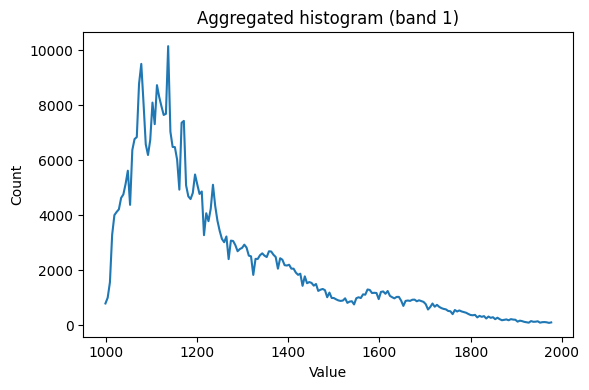

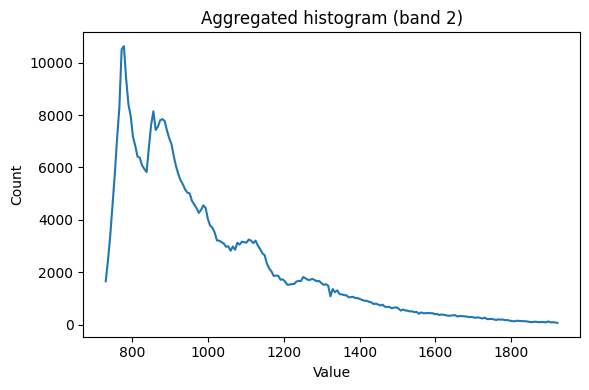

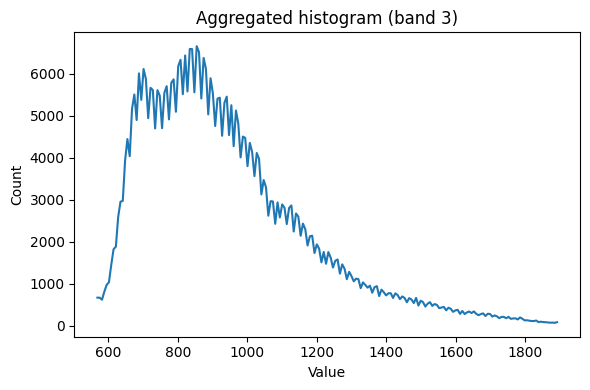

In [29]:
def aggregate_histograms(roi_dirs, band_stats_df, n_roi_sample=20, n_patch_per_roi=5, bins=200, seed=SEED):
    if not roi_dirs:
        print("No ROI dirs provided.")
        return None, None, None, []
    rng = random.Random(seed)
    roi_sample = rng.sample(roi_dirs, min(n_roi_sample, len(roi_dirs)))

    # Find band count from first readable file
    band_count = None
    for roi in roi_sample:
        for p in roi.glob("*.tif"):
            try:
                with rasterio.open(p) as ds:
                    band_count = ds.count
                break
            except RasterioIOError:
                continue
        if band_count is not None:
            break
    if band_count is None:
        print("No readable files in ROI sample.")
        return None, None, None, []

    # Build per-band bin edges from global percentiles
    edges = {}
    for b in range(1, band_count + 1):
        if band_stats_df is not None and b in band_stats_df.index:
            p1 = band_stats_df.loc[b, "p1"]
            p99 = band_stats_df.loc[b, "p99"]
            if not np.isfinite(p1) or not np.isfinite(p99) or p1 >= p99:
                p1 = band_stats_df.loc[b, "min"]
                p99 = band_stats_df.loc[b, "max"]
        else:
            p1, p99 = 0.0, 1.0
        if not np.isfinite(p1) or not np.isfinite(p99) or p1 >= p99:
            p1, p99 = 0.0, 1.0
        edges[b] = np.linspace(p1, p99, bins + 1)

    global_hist = {b: np.zeros(bins, dtype=np.float64) for b in range(1, band_count + 1)}
    roi_hist = {roi.name: {b: np.zeros(bins, dtype=np.float64) for b in range(1, band_count + 1)} for roi in roi_sample}
    failures = []

    for roi in roi_sample:
        patches = sample_patches_in_roi(roi, n_patch_per_roi, seed=rng.randint(0, 10**9))
        for p in patches:
            try:
                with rasterio.open(p) as ds:
                    if ds.count != band_count:
                        continue
                    arr = ds.read().astype(np.float64)
                    nodata = ds.nodata
            except RasterioIOError as e:
                failures.append((p, str(e)))
                continue

            for b in range(band_count):
                x = arr[b]
                if nodata is not None:
                    x = np.where(x == nodata, np.nan, x)
                x = x[np.isfinite(x)]
                if x.size == 0:
                    continue
                if x.size > PIXELS_PER_FILE:
                    idx = np.random.choice(x.size, size=PIXELS_PER_FILE, replace=False)
                    x = x[idx]
                h, _ = np.histogram(x, bins=edges[b + 1])
                roi_hist[roi.name][b + 1] += h
                global_hist[b + 1] += h

    return roi_hist, global_hist, edges, failures


def _cosine_similarity(a, b):
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-9))


roi_hist, global_hist, bin_edges, hist_failures = aggregate_histograms(
    roi_dirs,
    opt_global_stats_df,
    n_roi_sample=N_ROI_SAMPLE,
    n_patch_per_roi=N_PATCH_PER_ROI,
    bins=HIST_BINS,
    seed=SEED,
)

if roi_hist and global_hist:
    band_count = len(global_hist)
    plot_bands = [b for b in [1, 2, 3] if b <= band_count]

    for b in range(1, band_count + 1):
        sims = []
        for roi_name in roi_hist:
            sims.append((roi_name, _cosine_similarity(roi_hist[roi_name][b], global_hist[b])))
        sim_vals = [s for _, s in sims]
        if sim_vals:
            print(f"Band {b} cosine similarity (ROI vs global): min={np.min(sim_vals):.3f}, median={np.median(sim_vals):.3f}, max={np.max(sim_vals):.3f}")
            sims_sorted = sorted(sims, key=lambda x: x[1])
            print("  Lowest similarity ROIs:", [r for r, _ in sims_sorted[:3]])

    for b in plot_bands:
        centers = 0.5 * (bin_edges[b][:-1] + bin_edges[b][1:])
        plt.figure(figsize=(6, 4))
        plt.plot(centers, global_hist[b])
        plt.title(f"Aggregated histogram (band {b})")
        plt.xlabel("Value")
        plt.ylabel("Count")
        plt.tight_layout()
        plt.show()


Outlier ROIs (mean cosine similarity): ['s2_26']


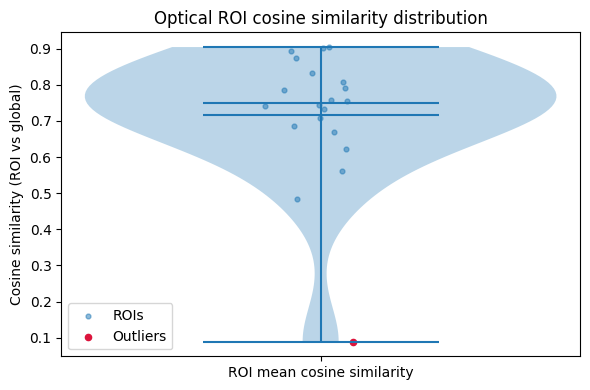

In [30]:
# Optical ROI cosine similarity distribution with highlighted outliers
if roi_hist and global_hist:
    per_roi = {}
    for roi_name in roi_hist:
        sims = []
        for b in range(1, len(global_hist) + 1):
            sims.append(_cosine_similarity(roi_hist[roi_name][b], global_hist[b]))
        sims = [s for s in sims if np.isfinite(s)]
        if sims:
            per_roi[roi_name] = float(np.mean(sims))

    if per_roi:
        roi_names = list(per_roi.keys())
        sim_vals = np.array([per_roi[r] for r in roi_names], dtype=float)

        q1 = np.percentile(sim_vals, 25)
        q3 = np.percentile(sim_vals, 75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        outlier_mask = (sim_vals < lower) | (sim_vals > upper)

        rng = np.random.default_rng(SEED)
        jitter = rng.normal(1.0, 0.03, size=sim_vals.size)

        fig, ax = plt.subplots(figsize=(6, 4))
        ax.violinplot([sim_vals], showmeans=True, showmedians=True)
        ax.scatter(jitter[~outlier_mask], sim_vals[~outlier_mask], s=12, alpha=0.5, label="ROIs")
        if outlier_mask.any():
            ax.scatter(jitter[outlier_mask], sim_vals[outlier_mask], s=20, color="crimson", label="Outliers")
            outlier_rois = [roi_names[i] for i in np.where(outlier_mask)[0]]
            print("Outlier ROIs (mean cosine similarity):", outlier_rois)

        ax.set_xticks([1])
        ax.set_xticklabels(["ROI mean cosine similarity"])
        ax.set_ylabel("Cosine similarity (ROI vs global)")
        ax.set_title("Optical ROI cosine similarity distribution")
        ax.legend(loc="best")
        plt.tight_layout()
    else:
        print("No finite cosine similarities to plot.")
else:
    print("Run the histogram aggregation cell first to compute ROI/global histograms.")


## Inter-band correlation analysis

Compute a band-to-band correlation matrix using random pixel sampling across sampled files.


,B1,B2,B3,B4,B5,B6,B7,B8,B9,B10,B11,B12,B13
B1,1.000000,0.930170,0.860450,0.844096,0.764143,-0.004341,-0.131092,-0.139535,-0.175117,-0.016948,0.172900,0.534350,0.710098
B2,0.930170,1.000000,0.958694,0.943698,0.852360,0.045641,-0.099017,-0.102302,-0.144192,0.016630,0.170646,0.630635,0.793265
B3,0.860450,0.958694,1.000000,0.958541,0.943337,0.238702,0.068349,0.064155,0.019322,0.094656,0.147508,0.732209,0.825460
B4,0.844096,0.943698,0.958541,1.000000,0.921539,0.054690,-0.112131,-0.116620,-0.157055,0.027288,0.174313,0.753609,0.887389
B5,0.764143,0.852360,0.943337,0.921539,1.000000,0.349161,0.154665,0.153978,0.108963,0.231426,0.169680,0.837270,0.870900
B6,-0.004341,0.045641,0.238702,0.054690,0.349161,1.000000,0.964696,0.952839,0.948995,0.421084,-0.096315,0.340842,0.084609
B7,-0.131092,-0.099017,0.068349,-0.112131,0.154665,0.964696,1.000000,0.980744,0.991546,0.352064,-0.136802,0.188777,-0.077409
B8,-0.139535,-0.102302,0.064155,-0.116620,0.153978,0.952839,0.980744,1.000000,0.974314,0.424343,-0.111389,0.184868,-0.072066
B9,-0.175117,-0.144192,0.019322,-0.157055,0.108963,0.948995,0.991546,0.974314,1.000000,0.307597,-0.152085,0.189040,-0.103759
B10,-0.016948,0.016630,0.094656,0.027288,0.231426,0.421084,0.352064,0.424343,0.307597,1.000000,0.292365,0.082397,0.097610


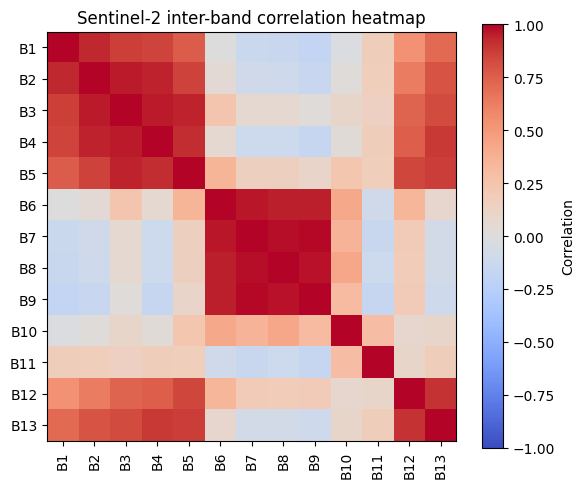

In [25]:
def sample_pixels_for_corr(paths, n_sample=30, pixels_per_file=5000, seed=SEED):
    if not paths:
        print("No paths provided.")
        return None, None, None, []
    rng = random.Random(seed)
    sample = paths if len(paths) <= n_sample else rng.sample(paths, n_sample)

    samples = []
    band_count = None
    labels = None
    failures = []

    for p in sample:
        try:
            with rasterio.open(p) as ds:
                arr = ds.read().astype(np.float64)
                nodata = ds.nodata
                if band_count is None:
                    band_count = arr.shape[0]
                    labels = list(ds.descriptions) if ds.descriptions else None
                if arr.shape[0] != band_count:
                    continue
        except RasterioIOError as e:
            failures.append((p, str(e)))
            continue

        h, w = arr.shape[1], arr.shape[2]
        n_pix = min(pixels_per_file, h * w)
        idx = np.random.choice(h * w, size=n_pix, replace=False)
        flat = arr.reshape(band_count, -1)
        if nodata is not None:
            flat = np.where(flat == nodata, np.nan, flat)
        samp = flat[:, idx].T
        mask = np.isfinite(samp).all(axis=1)
        samp = samp[mask]
        if samp.size:
            samples.append(samp)

    if not samples:
        print("No valid samples for correlation.")
        return None, None, None, failures

    X = np.concatenate(samples, axis=0)
    return X, labels, band_count, failures


corr_X, corr_labels, corr_band_count, corr_failures = sample_pixels_for_corr(
    sample_paths,
    n_sample=min(N_SAMPLE, len(sample_paths)),
    pixels_per_file=PIXELS_PER_FILE,
    seed=SEED,
)

if corr_X is not None:
    band_labels = _normalize_labels(corr_labels, corr_band_count)
    corr = np.corrcoef(corr_X, rowvar=False)
    opt_corr_df = pd.DataFrame(corr, index=band_labels, columns=band_labels)
    display(opt_corr_df)

    plt.figure(figsize=(6, 5))
    plt.imshow(corr, vmin=-1, vmax=1, cmap="coolwarm")
    plt.title("Sentinel-2 inter-band correlation heatmap")
    plt.colorbar(label="Correlation")
    plt.xticks(range(corr_band_count), band_labels, rotation=90)
    plt.yticks(range(corr_band_count), band_labels)
    plt.tight_layout()
    plt.show()


## NDVI check (if RGB/NIR bands can be inferred)

Attempt NDVI using plausible red/NIR band mappings and proceed only if NDVI values are mostly within [-1, 1].


Using NDVI mapping: red band 4, nir band 8 (default)
NDVI stats: mean=0.502, std=0.235, p1=-0.123, p99=0.835


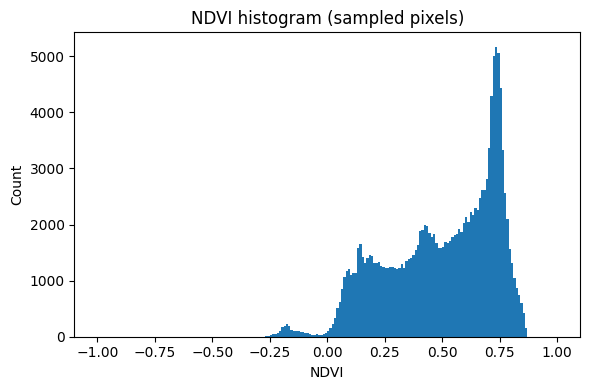

In [26]:
def _find_band_index(labels, keys):
    if not labels:
        return None
    for i, lab in enumerate(labels):
        if lab and any(k in lab.lower() for k in keys):
            return i
    return None


def try_ndvi(sample_X, labels, band_count):
    if sample_X is None:
        print("No samples for NDVI.")
        return None, None

    candidates = []
    r = _find_band_index(labels, ["b04", "b4", "red"])
    n = _find_band_index(labels, ["b08", "b8", "nir", "b8a"])
    if r is not None and n is not None:
        candidates.append((r, n, "labels"))

    # Default Sentinel-2 ordering (1-based: B04=4, B08=8)
    default_pairs = [(3, 7), (3, 6), (2, 6)]
    for r0, n0 in default_pairs:
        if r0 < band_count and n0 < band_count:
            candidates.append((r0, n0, "default"))

    for r_idx, n_idx, tag in candidates:
        red = sample_X[:, r_idx]
        nir = sample_X[:, n_idx]
        ndvi = (nir - red) / (nir + red + 1e-6)
        finite = np.isfinite(ndvi)
        if finite.mean() < 0.5:
            continue
        in_range = np.mean((ndvi[finite] >= -1.05) & (ndvi[finite] <= 1.05))
        if in_range >= 0.98:
            print(f"Using NDVI mapping: red band {r_idx+1}, nir band {n_idx+1} ({tag})")
            return ndvi[finite], (r_idx + 1, n_idx + 1)

    print("Could not find a reliable NDVI mapping.")
    return None, None


ndvi_vals, ndvi_pair = try_ndvi(corr_X, corr_labels, corr_band_count if corr_band_count else 0)

if ndvi_vals is not None:
    p1, p99 = np.percentile(ndvi_vals, [1, 99])
    print(f"NDVI stats: mean={np.mean(ndvi_vals):.3f}, std={np.std(ndvi_vals):.3f}, p1={p1:.3f}, p99={p99:.3f}")
    plt.figure(figsize=(6, 4))
    plt.hist(ndvi_vals, bins=HIST_BINS, range=(-1, 1))
    plt.title("NDVI histogram (sampled pixels)")
    plt.xlabel("NDVI")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()


## ROI-level statistics

Compute per-ROI band means (sampled) and compare each ROI to the global mean vector.


In [31]:
def compute_roi_deviation(roi_dirs, global_mean, n_roi_sample=20, n_patch_per_roi=5, pixels_per_file=5000, seed=SEED):
    if not roi_dirs or global_mean is None:
        print("Missing ROI dirs or global mean.")
        return None

    rng = random.Random(seed)
    roi_sample = rng.sample(roi_dirs, min(n_roi_sample, len(roi_dirs)))

    band_count = len(global_mean)
    rows = []
    deviations = []

    for roi in roi_sample:
        patches = sample_patches_in_roi(roi, n_patch_per_roi, seed=rng.randint(0, 10**9))
        band_vals = {b: [] for b in range(band_count)}

        for p in patches:
            try:
                with rasterio.open(p) as ds:
                    if ds.count != band_count:
                        continue
                    arr = ds.read().astype(np.float64)
                    nodata = ds.nodata
            except RasterioIOError:
                continue

            for b in range(band_count):
                x = arr[b]
                if nodata is not None:
                    x = np.where(x == nodata, np.nan, x)
                x = x[np.isfinite(x)]
                if x.size == 0:
                    continue
                if x.size > pixels_per_file:
                    idx = np.random.choice(x.size, size=pixels_per_file, replace=False)
                    x = x[idx]
                band_vals[b].append(x)

        mean_vec = np.array([
            float(np.mean(np.concatenate(band_vals[b]))) if band_vals[b] else np.nan
            for b in range(band_count)
        ])
        deviation = float(np.linalg.norm(mean_vec - global_mean))
        deviations.append(mean_vec - global_mean)

        rows.append({
            "roi": roi.name,
            "deviation": deviation,
            "n_patches": len(patches),
        })

    df = pd.DataFrame(rows).sort_values("deviation", ascending=False).reset_index(drop=True)
    dev_arr = np.vstack(deviations) if deviations else np.array([])
    return df, dev_arr


if opt_global_stats_df is not None:
    global_mean = opt_global_stats_df["mean"].values
else:
    global_mean = None

roi_deviation_result = compute_roi_deviation(
    roi_dirs,
    global_mean,
    n_roi_sample=N_ROI_SAMPLE,
    n_patch_per_roi=N_PATCH_PER_ROI,
    pixels_per_file=PIXELS_PER_FILE,
    seed=SEED,
)

if roi_deviation_result is not None:
    roi_deviation_df, roi_dev_arr = roi_deviation_result
    display(roi_deviation_df.head(10))
    if roi_dev_arr.size:
        mean_abs_dev = np.nanmean(np.abs(roi_dev_arr), axis=0)
        band_labels = _normalize_labels(corr_labels, len(mean_abs_dev)) if corr_labels else [f"B{i+1}" for i in range(len(mean_abs_dev))]
        dev_df = pd.DataFrame({"band": band_labels, "mean_abs_dev": mean_abs_dev})
        display(dev_df)


,roi,deviation,n_patches
0,s2_26,15688.625577,5
1,s2_8,4144.011567,5
2,s2_110,3430.400113,5
3,s2_123,2744.822697,5
4,s2_63,1739.645537,5
5,s2_100,1540.467459,5
6,s2_143,1224.157346,5
7,s2_45,1144.961181,5
8,s2_83,1102.751351,5
9,s2_122,1068.690424,5


,band,mean_abs_dev
0,B1,412.674330
1,B2,426.523942
2,B3,403.746949
3,B4,489.573569
4,B5,500.397221
5,B6,598.738382
6,B7,685.985876
7,B8,644.319735
8,B9,713.802369
9,B10,378.323556


### Per-band ROI variance / coefficient of variation

Summarize across-ROI variability per band using variance and CV of ROI mean vectors.

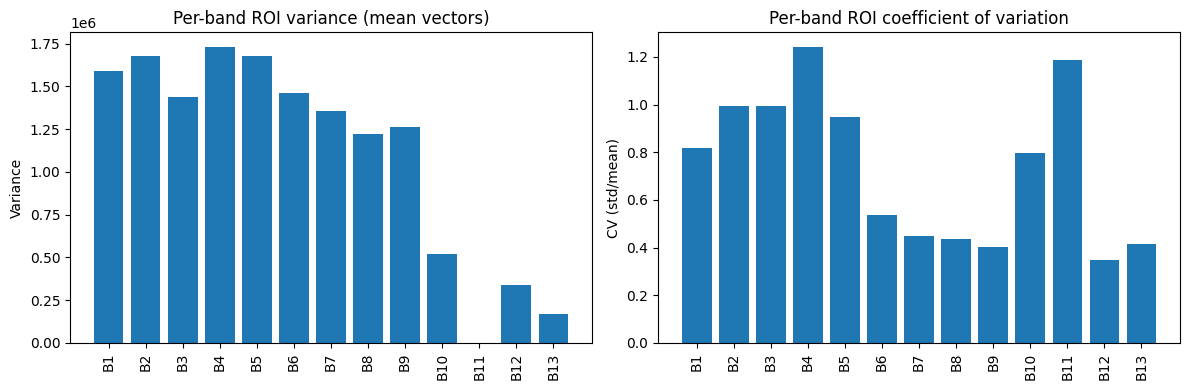

In [32]:
# Per-band ROI variance / coefficient of variation plot
if 'roi_dev_arr' in globals() and roi_dev_arr is not None and roi_dev_arr.size and global_mean is not None:
    roi_means = roi_dev_arr + global_mean[None, :]
    band_labels = _normalize_labels(corr_labels, roi_means.shape[1]) if corr_labels else [f"B{i+1}" for i in range(roi_means.shape[1])]

    var = np.nanvar(roi_means, axis=0)
    std = np.nanstd(roi_means, axis=0)
    mean = np.nanmean(roi_means, axis=0)
    denom = np.where(np.abs(mean) < 1e-9, np.nan, np.abs(mean))
    cv = std / denom

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    x = np.arange(len(band_labels))

    axes[0].bar(x, var)
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(band_labels, rotation=90)
    axes[0].set_title('Per-band ROI variance (mean vectors)')
    axes[0].set_ylabel('Variance')

    axes[1].bar(x, cv)
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(band_labels, rotation=90)
    axes[1].set_title('Per-band ROI coefficient of variation')
    axes[1].set_ylabel('CV (std/mean)')

    plt.tight_layout()
else:
    print('ROI deviation data not available for variance/CV plot.')


## Outliers and QC flags

Identify potential issues such as unreadable files, abnormal shapes, high zero/nan fractions, or dead bands.


In [28]:
qc_failures = []
if consistency and consistency.get("failures"):
    qc_failures.extend(consistency["failures"])
if agg_failures:
    qc_failures.extend(agg_failures)
if hist_failures:
    qc_failures.extend(hist_failures)
if corr_failures:
    qc_failures.extend(corr_failures)

print(f"Unreadable files (sampled): {len(qc_failures)}")
if qc_failures:
    for f in qc_failures[:5]:
        print(" ", f[0])

if consistency:
    if len(consistency.get("shapes", [])) > 1:
        print("Warning: multiple shapes detected in sample.")
    if len(consistency.get("counts", [])) > 1:
        print("Warning: multiple band counts detected in sample.")

if per_file_band_stats:
    df_pf = pd.DataFrame(per_file_band_stats)
    high_zero = df_pf[df_pf["zero_frac"] > 0.5]
    high_nan = df_pf[df_pf["nan_frac"] > 0.1]
    print(f"Files with zero_frac > 0.5 (band-level): {len(high_zero)}")
    print(f"Files with nan_frac > 0.1 (band-level): {len(high_nan)}")

    const_frac = df_pf.groupby("band")["std"].apply(lambda s: np.mean(s < 1e-6))
    if len(const_frac):
        print("Fraction of near-constant files per band (std < 1e-6):")
        display(const_frac)


Unreadable files (sampled): 0
Files with zero_frac > 0.5 (band-level): 0
Files with nan_frac > 0.1 (band-level): 0
Fraction of near-constant files per band (std < 1e-6):


band
1     0.0
2     0.0
3     0.0
4     0.0
5     0.0
6     0.0
7     0.0
8     0.0
9     0.0
10    0.0
11    0.0
12    0.0
13    0.0
Name: std, dtype: float64

## Saved summary variables

Key outputs saved for reuse:

- `opt_global_stats_df`
- `opt_corr_df`
- `roi_deviation_df`


In [16]:
print("opt_global_stats_df:", None if opt_global_stats_df is None else opt_global_stats_df.shape)
print("opt_corr_df:", None if opt_corr_df is None else opt_corr_df.shape)
print("roi_deviation_df:", None if roi_deviation_df is None else roi_deviation_df.shape)


opt_global_stats_df: (13, 11)
opt_corr_df: (13, 13)
roi_deviation_df: (20, 3)
